Pricing supplement: https://www.sec.gov/Archives/edgar/data/1666268/000183988225003212/ms5699_424b2-01572.htm

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy.stats import norm
from scipy.interpolate import interp1d

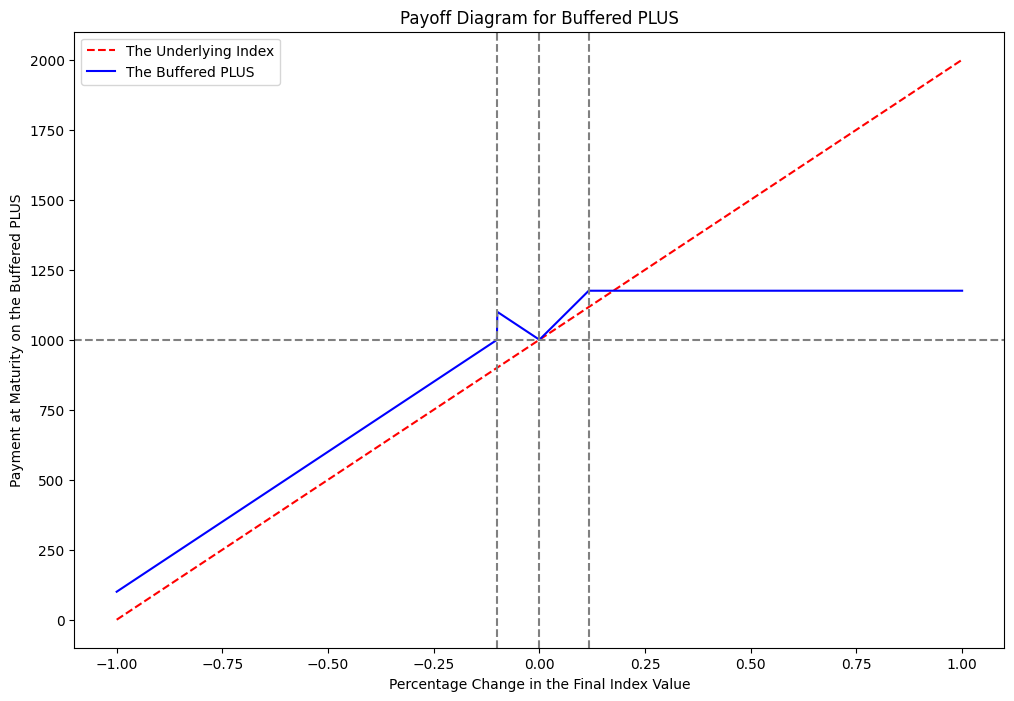

In [3]:
S0 = 5996.66
St = np.linspace(0, 2 * S0, 2000)
payoff = np.zeros_like(St)

con1 = St > S0
payoff[con1] = np.minimum(1000 + (1000 * 1.5 * (St[con1] - S0) / S0), 1175)

con2  = (St >= 0.9 * S0) & (St <= S0)
payoff[con2] = 1000 + 1000 * np.abs((St[con2] - S0) / S0)

con3 = (St < 0.9 * S0)
payoff[con3] = 1000 * St[con3] / S0 + 100

ret = (St - S0) / S0
plt.figure(figsize=(12,8))
plt.plot(ret, np.linspace(0, 2000, 2000), label="The Underlying Index", color="red", linestyle="--")
plt.plot(ret, payoff, label="The Buffered PLUS", color="blue")
plt.axhline(y=1000, color="gray", linestyle="--")
plt.axvline(x=-0.1, color="gray", linestyle="--")
plt.axvline(x=0, color="gray", linestyle="--")
plt.axvline(x=0.11667, color="gray", linestyle="--")
plt.title("Payoff Diagram for Buffered PLUS")
plt.xlabel("Percentage Change in the Final Index Value")
plt.ylabel("Payment at Maturity on the Buffered PLUS")
plt.legend()

## Static option replication

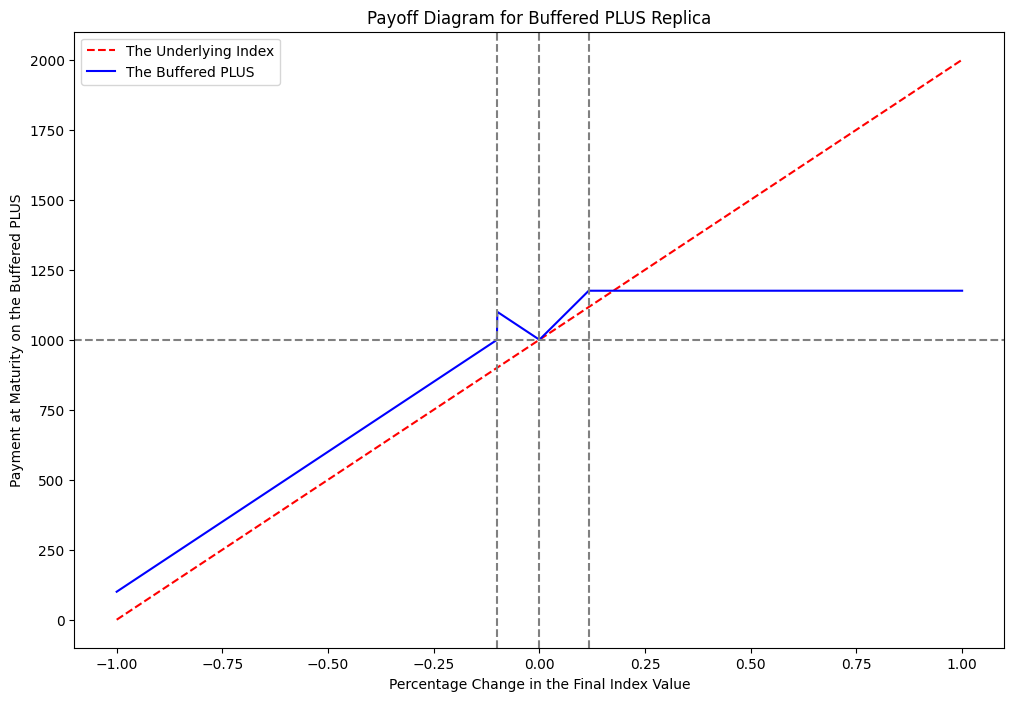

In [4]:
# Start at x=0, buy bond with par value $1000
bond = lambda x: 1000
# To right:
# Long 1000*150%/S0 call at strike S0
call_n1 = 1000 * 1.5 / S0
call_k1 = S0
call_payoff1 = lambda x: call_n1 * np.maximum(x - call_k1, 0)
# Short 1000*150%/S0 call at strike 1.11666667*S0
call_n2 = -call_n1
call_k2 = ((1175 - 1000) / (1000 * 1.5) + 1) * S0
call_payoff2 = lambda x: call_n2 * np.maximum(x - call_k2, 0)
# To left:
# Long 1000/S0 put at strike S0
put_n1 = 1000 / S0
put_k1 = S0
put_payoff1 = lambda x: put_n1 * np.maximum(put_k1 - x, 0)
# Short 100 digital put at strike 0.9*S0
put_digital_n = -100
put_digital_k = 0.9 * S0
put_digital_payoff = lambda x: put_digital_n * np.where(x < put_digital_k, 1, 0)
# Short 2000/S0 put at strike 0.9*S0
put_n2 = -put_n1 - 1000 / S0
put_k2 = 0.9 * S0
put_payoff2 = lambda x: put_n2 * np.maximum(put_k2 - x, 0)
# Sum up to replicate Buffered PLUS
payoff = bond(St) + call_payoff1(St) + call_payoff2(St) + put_payoff1(St) + put_digital_payoff(St) + put_payoff2(St)

ret = (St - S0) / S0
plt.figure(figsize=(12,8))
plt.plot(ret, np.linspace(0, 2000, 2000), label="The Underlying Index", color="red", linestyle="--")
plt.plot(ret, payoff, label="The Buffered PLUS", color="blue")
plt.axhline(y=1000, color="gray", linestyle="--")
plt.axvline(x=-0.1, color="gray", linestyle="--")
plt.axvline(x=0, color="gray", linestyle="--")
plt.axvline(x=0.11667, color="gray", linestyle="--")
plt.title("Payoff Diagram for Buffered PLUS Replica")
plt.xlabel("Percentage Change in the Final Index Value")
plt.ylabel("Payment at Maturity on the Buffered PLUS")
plt.legend()

In [5]:
def bsm_european(S0, dT02, dT13, K, r02, r13, q, sigma, cp_flag):
    d1 = (np.log(S0 / K) + (r02 - q + 0.5 * sigma**2) * dT02) / (sigma * np.sqrt(dT02))
    d2 = d1 - sigma * np.sqrt(dT02)
    if cp_flag == 'C':
        N1 = norm.cdf(d1)
        N2 = norm.cdf(d2)
        C = np.exp(-r13*dT13) * (S0 * np.exp((r02 - q) * dT02) * N1 - K * N2)
        return C
    elif cp_flag == 'P':
        N1 = norm.cdf(-d1)
        N2 = norm.cdf(-d2)
        P = np.exp(-r13*dT13) * (K * N2 - S0 * np.exp((r02 - q) * dT02) * N1)
        return P

def bsm_digital(S0, dT02, dT13, K, r02, r13, q, sigma, cp_flag):
    d2 = (np.log(S0 / K) + (r02 - q - 0.5 * sigma**2) * dT02) / (sigma * np.sqrt(dT02))
    if cp_flag == 'C':
        return np.exp(-r13*dT13) * norm.cdf(d2)
    elif cp_flag == 'P':
        return np.exp(-r13*dT13) * norm.cdf(-d2)


In [6]:
pricing_date = datetime.date(2025, 1, 17)    # T0
issue_date = datetime.date(2025, 1, 23)      # T1
valuation_date = datetime.date(2027, 1, 29)  # T2
maturity_date = datetime.date(2027, 2, 3)    # T3

dT02 = (valuation_date - pricing_date).days / 365
dT13 = (maturity_date - issue_date).days / 365

In [7]:
vol = 0.12543  # Estimated voltility
div = 0.01327  # Dividend yield from Bloomberg
# discount_structure02 = pd.read_excel(...)  # OIS term structure at pricing date
# discount02 = inerp1d(..., ..., kind='linear')(dT02)  # Discount factor between pricing date and valuation date
discount02 = interp1d([datetime.datetime(2027, 1, 22).timestamp(), datetime.datetime(2028, 1, 24).timestamp()],
                     [0.920675, 0.883969], kind='linear')(datetime.datetime(2027, 1, 29).timestamp())
r02 = -np.log(discount02) / dT02
# discount_structure13 = pd.read_excel(...)  # OIS term structure at issue date
# discount13 = inerp1d(..., ..., kind='linear')(dT13)  # Discount factor between issue date and maturity date
discount13 = interp1d([datetime.datetime(2027, 1, 27).timestamp(), datetime.datetime(2028, 1, 27).timestamp()],
                     [0.921108, 0.884590], kind='linear')(datetime.datetime(2027, 2, 23).timestamp())
r13 = -np.log(discount13) / dT13

Buffered_PLUS = bond(0) * discount13  + \
                call_n1 * bsm_european(S0, dT02, dT13, call_k1, r02, r13, div, vol, 'C') + \
                call_n2 * bsm_european(S0, dT02, dT13, call_k2, r02, r13, div, vol, 'C') + \
                put_n1 * bsm_european(S0, dT02, dT13, put_k1, r02, r13, div, vol, 'P') + \
                put_digital_n * bsm_digital(S0, dT02, dT13, put_digital_k, r02, r13, div, vol, 'P') + \
                put_n2 * bsm_european(S0, dT02, dT13, put_k2, r02, r13, div, vol, 'P')
print(f"Estimated value is {Buffered_PLUS}.")

Estimated value is 986.3148567486197.


In [8]:
discount02,discount13

(array(0.91997489), array(0.91840667))

## Sensitivity analysis

Approximate sensitivity to riskfree rate: -890.67


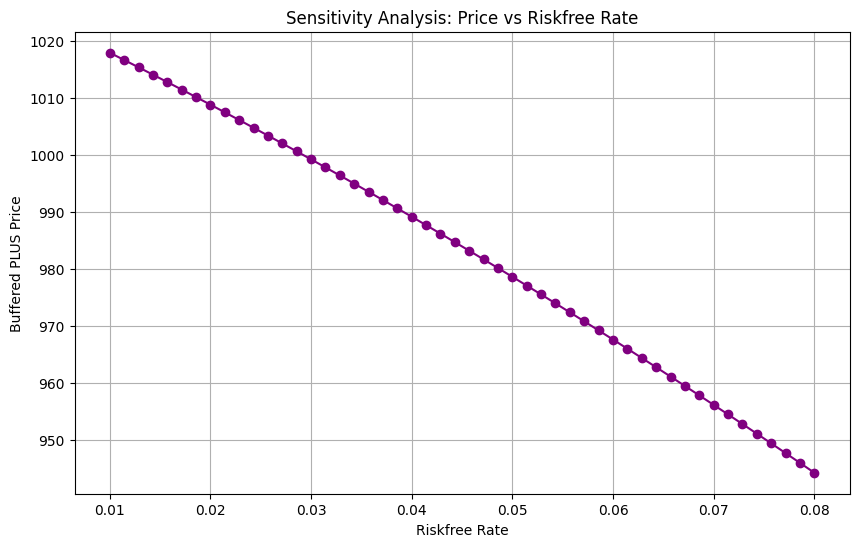

In [ ]:
def price_buffered_plus_rf(new_rf, volatility=vol, dividend=div):
    discount13_new = np.exp(-new_rf * dT13)
    price = bond(0) * discount13_new + \
            call_n1 * bsm_european(S0, dT02, dT13, call_k1, new_rf, new_rf, dividend, volatility, 'C') + \
            call_n2 * bsm_european(S0, dT02, dT13, call_k2, new_rf, new_rf, dividend, volatility, 'C') + \
            put_n1 * bsm_european(S0, dT02, dT13, put_k1, new_rf, new_rf, dividend, volatility, 'P') + \
            put_digital_n * bsm_digital(S0, dT02, dT13, put_digital_k, new_rf, new_rf, dividend, volatility, 'P') + \
            put_n2 * bsm_european(S0, dT02, dT13, put_k2, new_rf, new_rf, dividend, volatility, 'P')
    return price

rf_range = np.linspace(0.01, 0.08, 50)
prices_rf = np.array([price_buffered_plus_rf(rf) for rf in rf_range])
rf_sensitivity = (prices_rf[1] - prices_rf[0]) / (rf_range[1] - rf_range[0])
print(f"Approximate sensitivity to riskfree rate: {rf_sensitivity:.2f}")

plt.figure(figsize=(10,6))
plt.plot(rf_range, prices_rf, marker='o', color='purple')
plt.xlabel('Riskfree Rate')
plt.ylabel('Buffered PLUS Price')
plt.title('Sensitivity Analysis: Price vs Riskfree Rate')
plt.grid(True)
plt.show()

Approximate sensitivity to time to maturity: -43.11


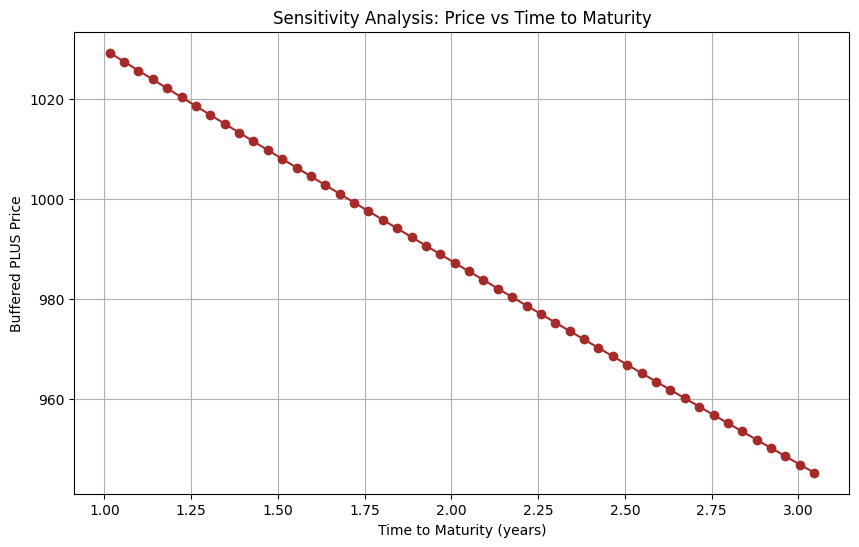

In [ ]:
def price_buffered_plus_maturity(new_dT13, volatility=vol, dividend=div, r_fixed=r13):
    discount13_new = np.exp(-r_fixed * new_dT13)
    price = bond(0) * discount13_new + \
            call_n1 * bsm_european(S0, dT02, new_dT13, call_k1, r02, r_fixed, dividend, volatility, 'C') + \
            call_n2 * bsm_european(S0, dT02, new_dT13, call_k2, r02, r_fixed, dividend, volatility, 'C') + \
            put_n1 * bsm_european(S0, dT02, new_dT13, put_k1, r02, r_fixed, dividend, volatility, 'P') + \
            put_digital_n * bsm_digital(S0, dT02, new_dT13, put_digital_k, r02, r_fixed, dividend, volatility, 'P') + \
            put_n2 * bsm_european(S0, dT02, new_dT13, put_k2, r02, r_fixed, dividend, volatility, 'P')
    return price

dT13_range = np.linspace(0.5 * dT13, 1.5 * dT13, 50)
prices_maturity = np.array([price_buffered_plus_maturity(new_dT13) for new_dT13 in dT13_range])
maturity_sensitivity = (prices_maturity[1] - prices_maturity[0]) / (dT13_range[1] - dT13_range[0])
print(f"Approximate sensitivity to time to maturity: {maturity_sensitivity:.2f}")

plt.figure(figsize=(10,6))
plt.plot(dT13_range, prices_maturity, marker='o', color='brown')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Buffered PLUS Price')
plt.title('Sensitivity Analysis: Price vs Time to Maturity')
plt.grid(True)
plt.show()

Approximate Vega (price sensitivity to volatility): -223.25


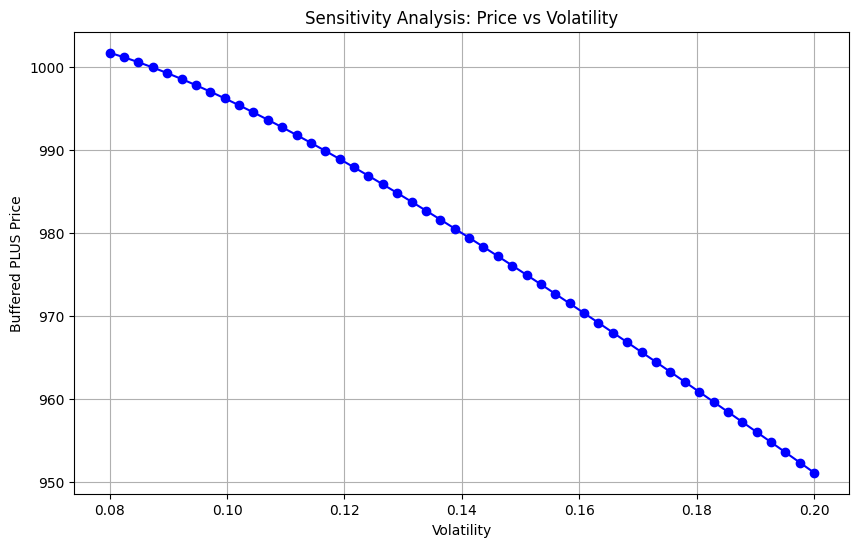

In [ ]:
def price_buffered_plus(volatility, dividend=div):
    price = bond(0) * discount13  + \
            call_n1 * bsm_european(S0, dT02, dT13, call_k1, r02, r13, dividend, volatility, 'C') + \
            call_n2 * bsm_european(S0, dT02, dT13, call_k2, r02, r13, dividend, volatility, 'C') + \
            put_n1 * bsm_european(S0, dT02, dT13, put_k1, r02, r13, dividend, volatility, 'P') + \
            put_digital_n * bsm_digital(S0, dT02, dT13, put_digital_k, r02, r13, dividend, volatility, 'P') + \
            put_n2 * bsm_european(S0, dT02, dT13, put_k2, r02, r13, dividend, volatility, 'P')
    return price

vol_range = np.linspace(0.08, 0.20, 50)
prices_vol = np.array([price_buffered_plus(vol_i) for vol_i in vol_range])
vega_approx = (prices_vol[1] - prices_vol[0]) / (vol_range[1] - vol_range[0])
print(f"Approximate Vega (price sensitivity to volatility): {vega_approx:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(vol_range, prices_vol, marker='o', color='blue')
plt.xlabel('Volatility')
plt.ylabel('Buffered PLUS Price')
plt.title('Sensitivity Analysis: Price vs Volatility')
plt.grid(True)
plt.show()

Approximate sensitivity to dividend yield: -929.20


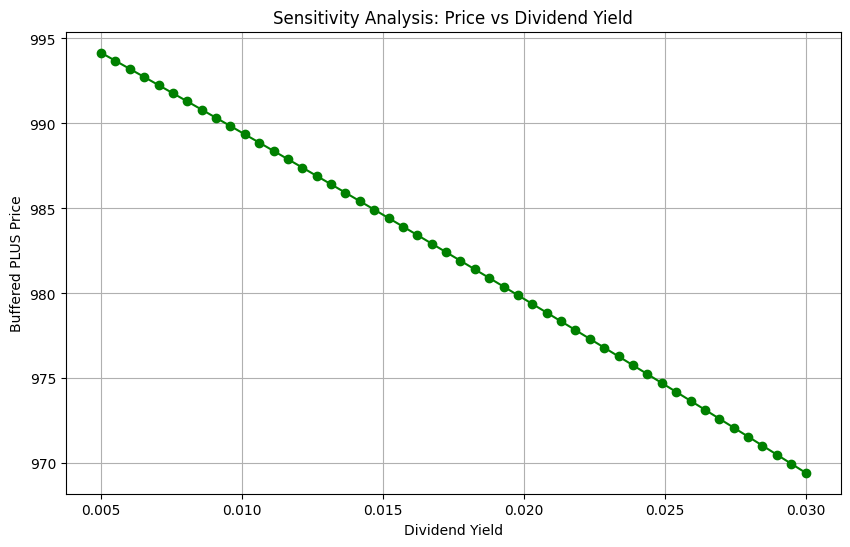

In [ ]:
div_range = np.linspace(0.005, 0.03, 50)
prices_div = np.array([price_buffered_plus(vol, dividend=div_i) for div_i in div_range])

div_sensitivity = (prices_div[1] - prices_div[0]) / (div_range[1] - div_range[0])
print(f"Approximate sensitivity to dividend yield: {div_sensitivity:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(div_range, prices_div, marker='o', color='green')
plt.xlabel('Dividend Yield')
plt.ylabel('Buffered PLUS Price')
plt.title('Sensitivity Analysis: Price vs Dividend Yield')
plt.grid(True)
plt.show()